# CanAI Café — Forecasting Model
**Owner:** Member C  
**Input:** `../data/clean/data_clean.csv`  
**Output:** `../outputs/forecast_results.csv`

**Structure:**
1. Data Preparation — load, aggregate, configure shared TimeSeriesSplit  
2. Series Visualisation  
3. Prophet — evaluate across folds, store metrics  
4. SARIMA — evaluate across folds, store metrics  
5. XGBoost — evaluate across folds, store metrics  
6. Model Comparison — side-by-side metrics table, select winner  
7. Final Forecast & Export — refit winner on full data, save `forecast_results.csv`

In [94]:
import sys
import os
import importlib
sys.path.insert(0, os.path.abspath('../models'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [95]:
import mlflow_setup
mlflow_setup.setup()
print(f"Tracking URI : {mlflow_setup.TRACKING_URI}")
print(f"Experiment   : {mlflow_setup.EXPERIMENT_NAME}")

Tracking URI : file:///c:/canai-cafe-team-a/mlruns
Experiment   : canai-cafe-forecasting


## MLflow Tracking

All three model modules log to the shared experiment **`canai-cafe-forecasting`** stored under `mlruns/` at the project root.

To open the tracking UI, run this from the project root:
```
mlflow ui --backend-store-uri ./mlruns --port 5000
```
Then open **http://localhost:5000**

## 1. Data Preparation

In [96]:
df = pd.read_csv('../data/clean/data_clean.csv', parse_dates=['Transaction Date'])

# Aggregate to daily total revenue — shared input for all three models
daily_revenue = (
    df.groupby('Transaction Date')['Total Spent']
    .sum()
    .sort_index()
    .rename('revenue')
)

print(f"Series: {len(daily_revenue)} days")
print(f"Range:  {daily_revenue.index.min().date()} to {daily_revenue.index.max().date()}")
print(f"Daily mean: ${daily_revenue.mean():.2f} | std: ${daily_revenue.std():.2f}")

# Walk-forward cross-validation — identical across all three models (see docs/model_selection_rationale.md §6.3)
tscv = TimeSeriesSplit(n_splits=5, test_size=30)
print(f"\nTimeSeriesSplit: {tscv.n_splits} folds, 30-day test windows")

Series: 365 days
Range:  2023-01-01 to 2023-12-31
Daily mean: $224.47 | std: $100.16

TimeSeriesSplit: 5 folds, 30-day test windows


## 2. Series Visualisation

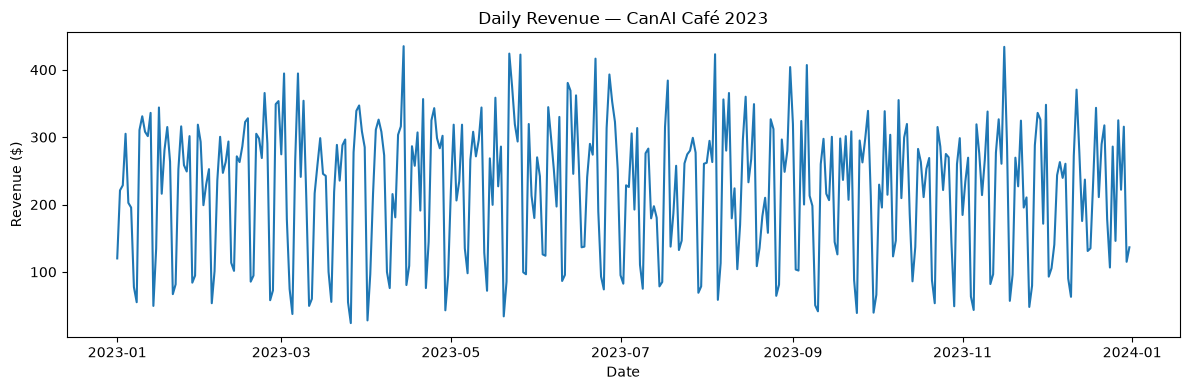

In [97]:
plt.figure(figsize=(12, 4))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title('Daily Revenue — CanAI Café 2023')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

## 3. Prophet

In [98]:
import prophet_model
importlib.reload(prophet_model)

prophet_metrics = prophet_model.evaluate(daily_revenue, tscv)
prophet_metrics

{'fold_mae': [50.96672436813876,
  46.037215784518565,
  39.88735778351021,
  38.09418096221375,
  45.29980050090512],
 'fold_rmse': [np.float64(63.363707966389775),
  np.float64(56.04902208471769),
  np.float64(48.858510897505234),
  np.float64(51.8179726078691),
  np.float64(57.08838831711014)],
 'fold_mape': [np.float64(24.55710653301666),
  np.float64(34.61256162552736),
  np.float64(23.14911845736788),
  np.float64(21.445166422641748),
  np.float64(25.674707847678473)],
 'mean_mae': np.float64(44.05705587985728),
 'mean_rmse': np.float64(55.43552037471839),
 'mean_mape': np.float64(25.887732177246427)}

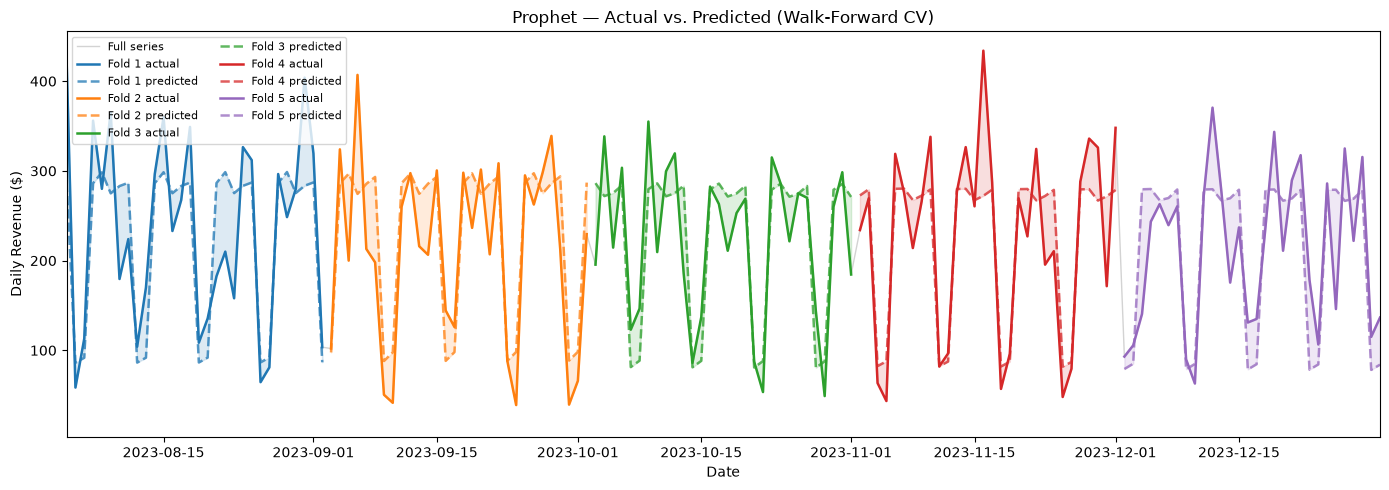

In [99]:
import os
os.makedirs('../outputs/charts/prophet', exist_ok=True)

# Determine where the first test window begins for x-axis cropping
first_test_start = daily_revenue.index[next(tscv.split(daily_revenue))[1][0]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_revenue.index, daily_revenue.values, color='lightgrey', linewidth=1, label='Full series')

colors = plt.cm.tab10.colors
for fold, (train_idx, test_idx) in enumerate(tscv.split(daily_revenue)):
    m = prophet_model.train(daily_revenue, train_idx)
    n_test = len(test_idx)
    future = m.make_future_dataframe(periods=n_test)
    fc = m.predict(future)

    test_dates = daily_revenue.iloc[test_idx].index
    actuals = daily_revenue.iloc[test_idx].values
    preds = fc.tail(n_test)["yhat"].values

    c = colors[fold]
    ax.plot(test_dates, actuals, color=c, linewidth=1.8, label=f'Fold {fold+1} actual')
    ax.plot(test_dates, preds, color=c, linewidth=1.8, linestyle='--', alpha=0.75, label=f'Fold {fold+1} predicted')
    ax.fill_between(test_dates, actuals, preds, color=c, alpha=0.15)

ax.set_xlim(left=first_test_start, right=daily_revenue.index[-1])
ax.set_title('Prophet — Actual vs. Predicted (Walk-Forward CV)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Revenue ($)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../outputs/charts/prophet/prophet_cv_actual_vs_predicted.png', dpi=150)
plt.show()

## 4. SARIMA

In [100]:
import sarima_model

sarima_metrics = sarima_model.evaluate(daily_revenue, tscv)
sarima_metrics

MlflowException: Changing param values is not allowed. Param with key='D' was already logged with value='0' for run ID='5e7aafb51f7a41be8ce0e240706ce63b'. Attempted logging new value '1'.

## 5. XGBoost

In [ ]:
import xgboost_model

xgboost_metrics = xgboost_model.evaluate(daily_revenue, tscv)
xgboost_metrics

## 6. Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model':     ['Prophet', 'SARIMA', 'XGBoost'],
    'Mean MAE':  [prophet_metrics['mean_mae'],  sarima_metrics['mean_mae'],  xgboost_metrics['mean_mae']],
    'Mean RMSE': [prophet_metrics['mean_rmse'], sarima_metrics['mean_rmse'], xgboost_metrics['mean_rmse']],
    'Mean MAPE': [prophet_metrics['mean_mape'], sarima_metrics['mean_mape'], xgboost_metrics['mean_mape']],
})
results = results.set_index('Model').round(2)

# Flag the winner (lowest MAPE)
winner = results['Mean MAPE'].idxmin()
print(f"Selected model: {winner}")
results

## 7. Final Forecast & Export

Refit the winning model on the full 365-day series, generate a 6-month forward forecast, and save `forecast_results.csv`.

In [ ]:
model_map = {
    'Prophet': prophet_model,
    'SARIMA':  sarima_model,
    'XGBoost': xgboost_model,
}

forecast_6m = model_map[winner].forecast(daily_revenue, periods=180)

# Aggregate daily forecast to monthly totals
forecast_6m.to_csv('../outputs/forecast_results.csv', index=False)
print('Saved: ../outputs/forecast_results.csv')
forecast_6m